In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

sys.path.append(os.path.abspath('../scripts'))
import ocean_analysis as oa 

c:\Users\Jelle Gortemaker\OneDrive - Delft University of Technology\Documenten\0. MSc\#.Thesis\Thesis\OGCM\scripts\ocean_analysis.py:688: RuntimeWarning: Mean of empty slice
  mean_zonal = np.nanmean(np.asarray(all_zonal_spectra), axis=0)
c:\Users\Jelle Gortemaker\OneDrive - Delft University of Technology\Documenten\0. MSc\#.Thesis\Thesis\OGCM\scripts\ocean_analysis.py:689: RuntimeWarning: Mean of empty slice
  mean_merid = np.nanmean(np.asarray(all_merid_spectra), axis=0)
c:\Users\Jelle Gortemaker\OneDrive - Delft University of Technology\Documenten\0. MSc\#.Thesis\Thesis\OGCM\scripts\ocean_analysis.py:688: RuntimeWarning: Mean of empty slice
  mean_zonal = np.nanmean(np.asarray(all_zonal_spectra), axis=0)
c:\Users\Jelle Gortemaker\OneDrive - Delft University of Technology\Documenten\0. MSc\#.Thesis\Thesis\OGCM\scripts\ocean_analysis.py:689: RuntimeWarning: Mean of empty slice
  mean_merid = np.nanmean(np.asarray(all_merid_spectra), axis=0)
c:\Users\Jelle Gortemaker\OneDrive - Delft U

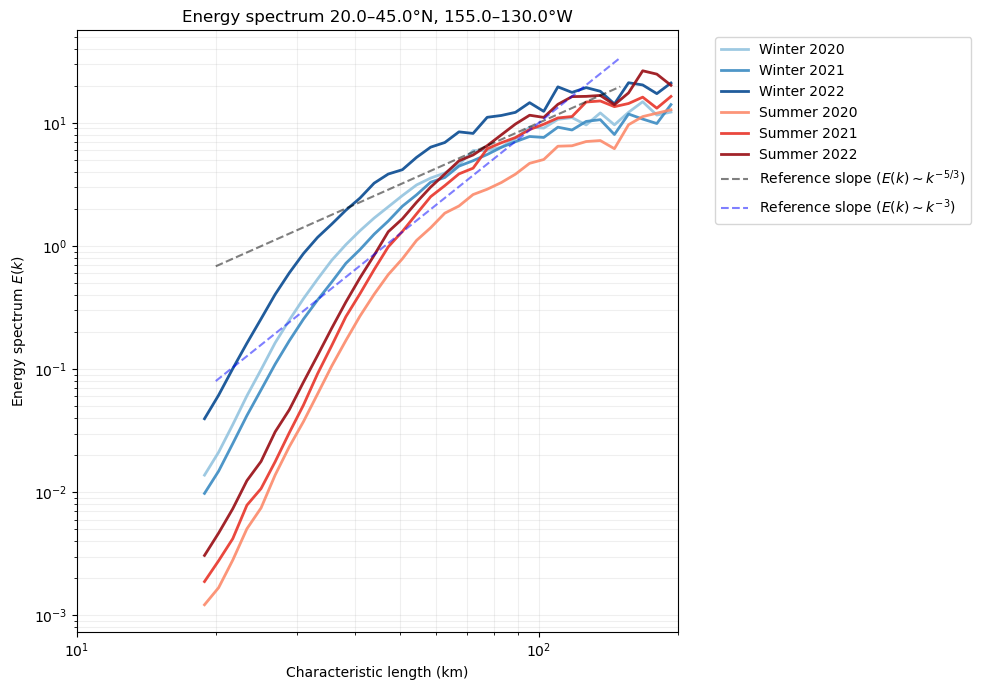

In [5]:
# 1. Define Subdomain
lat_s, lat_n = 20.0, 45.0
lon_w, lon_e = -155.0, -130.0

les_box = [lon_w, lon_e, lat_s, lat_n]

# 2. Setup Dataset Groups and Color Families
data_groups = {
    "Winter": {
        "2020": "../data/GPGP_jan2020.nc",
        "2021": "../data/GPGP_jan2021.nc",
        "2022": "../data/GPGP_jan2022.nc",
    },
    "Summer": {
        "2020": "../data/GPGP_aug2020.nc",
        "2021": "../data/GPGP_aug2021.nc",
        "2022": "../data/GPGP_aug2022.nc",
    },
}

base_colors = {
    "Winter": "Blues",
    "Summer": "Reds",
    "Spring": "Greens",
    "Autumn": "Oranges",
}

MAX_W = 200
plt.figure(figsize=(10, 7))

for season, years in data_groups.items():
    cmap = plt.get_cmap(base_colors[season])
    shades = np.linspace(0.4, 0.9, len(years))

    for idx, (year_label, path) in enumerate(years.items()):
        eds = oa.calculate_EDS(
            filepath=path,
            target_box=les_box,
            max_wavelength_km=MAX_W,
            initialized_velocity=False,
        )

        l_km = eds["characteristic_length"].values / 1000.0
        E = eds["energy_density_spectrum"].values

        plt.loglog(
            l_km,
            E,
            label=f"{season} {year_label}",
            color=cmap(shades[idx]),
            lw=2,
            alpha=0.9,
        )

# Initialized field EDS
eds_init = oa.calculate_EDS(
    filepath="../data/init_surface_uv.nc",
    target_box=None,
    max_wavelength_km=MAX_W,
    initialized_velocity=True,
    x_res=500.0,
    y_res=500.0,
)

l_km_init = eds_init["characteristic_length"].values / 1000.0
E_init = eds_init["energy_density_spectrum"].values

# plt.loglog(
#     l_km_init,
#     E_init,
#     label="Initial Surface UV",
#     color="black",
#     lw=3,
# )

# Reference slopes
x_ref = np.array([20.0, 150.0])
y_ref = 10**1 * (x_ref / 100.0) ** (5 / 3)
y_ref_enstrophy = 10**1 * (x_ref / 100.0) ** 3

plt.loglog(
    x_ref,
    y_ref,
    "k--",
    alpha=0.5,
    label=r"Reference slope ($E(k)\sim k^{-5/3}$)",
)

plt.loglog(
    x_ref,
    y_ref_enstrophy,
    "b--",
    alpha=0.5,
    label=r"Reference slope ($E(k)\sim k^{-3}$)",
)

plt.xlabel("Characteristic length (km)")
plt.ylabel(r"Energy spectrum $E(k)$")
plt.title(f"Energy spectrum {lat_s}–{lat_n}°N, {abs(lon_w)}–{abs(lon_e)}°W")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, which="both", alpha=0.2)

plt.xlim(10, MAX_W)
plt.tight_layout()
plt.show()

c:\Users\Jelle Gortemaker\OneDrive - Delft University of Technology\Documenten\0. MSc\#.Thesis\Thesis\OGCM\scripts\ocean_analysis.py:688: RuntimeWarning: Mean of empty slice
  mean_zonal = np.nanmean(np.asarray(all_zonal_spectra), axis=0)
c:\Users\Jelle Gortemaker\OneDrive - Delft University of Technology\Documenten\0. MSc\#.Thesis\Thesis\OGCM\scripts\ocean_analysis.py:689: RuntimeWarning: Mean of empty slice
  mean_merid = np.nanmean(np.asarray(all_merid_spectra), axis=0)
c:\Users\Jelle Gortemaker\OneDrive - Delft University of Technology\Documenten\0. MSc\#.Thesis\Thesis\OGCM\scripts\ocean_analysis.py:688: RuntimeWarning: Mean of empty slice
  mean_zonal = np.nanmean(np.asarray(all_zonal_spectra), axis=0)
c:\Users\Jelle Gortemaker\OneDrive - Delft University of Technology\Documenten\0. MSc\#.Thesis\Thesis\OGCM\scripts\ocean_analysis.py:689: RuntimeWarning: Mean of empty slice
  mean_merid = np.nanmean(np.asarray(all_merid_spectra), axis=0)
c:\Users\Jelle Gortemaker\OneDrive - Delft U

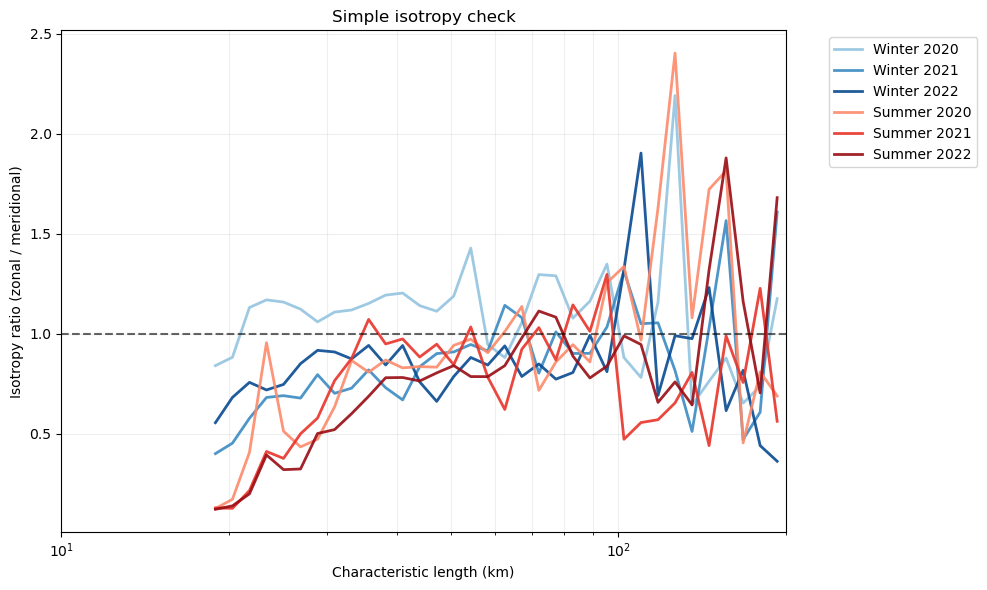

In [4]:
plt.figure(figsize=(10, 6))

for season, years in data_groups.items():
    cmap = plt.get_cmap(base_colors[season])
    shades = np.linspace(0.4, 0.9, len(years))

    for idx, (year_label, path) in enumerate(years.items()):
        eds = oa.calculate_EDS(
            filepath=path,
            target_box=les_box,
            max_wavelength_km=MAX_W,
            initialized_velocity=False,
        )

        l_km = eds["characteristic_length"].values / 1000.0
        R = eds["isotropy_ratio"].values

        plt.semilogx(
            l_km,
            R,
            label=f"{season} {year_label}",
            color=cmap(shades[idx]),
            lw=2,
            alpha=0.9,
        )

plt.axhline(1.0, color="k", linestyle="--", alpha=0.6)
plt.xlabel("Characteristic length (km)")
plt.ylabel("Isotropy ratio (zonal / meridional)")
plt.title("Simple isotropy check")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, which="both", alpha=0.2)
plt.xlim(10, MAX_W)
plt.tight_layout()
plt.show()